In [1]:
import pandas as pd
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Load numerical data (assuming whitespace-separated values)
import os 

directory = "H:/Other computers/My Computer/Salvatore/Confocal Raman/colon_sample/20260629_ihc_raman_colon_m1260614A_#3"

file_name = "1 0.55W 2um_320xsteps_320ysteps_1200msec.dat"
file_path = os.path.join(directory, file_name)
data = pd.read_csv(file_path)
print(data.shape)

(102399, 1340)


In [2]:
data.loc[102399, :] = 0

In [3]:
arr_data = np.array(data).reshape(320, 320, -1)

In [4]:
print(arr_data.shape)

(320, 320, 1340)


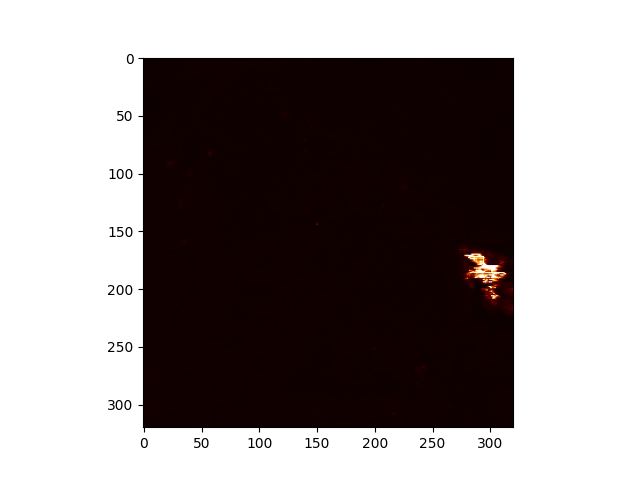

In [6]:
arr_data[0::2] = np.fliplr(arr_data[0::2])
arr_data = np.flip(arr_data, 1)

plt.figure()

vmin = np.percentile(arr_data[:, :, :], 1)
vmax = np.percentile(arr_data[:, :, :], 99.9)

plt.imshow(arr_data[:, :, 555], cmap='afmhot', vmin=vmin, vmax=vmax)

In [7]:
import scipy as sp
import skimage as ski
import pandas as pd

from scipy.signal import savgol_filter
import scipy.signal as sg

def remove_rays(intensity, win_size=9, threshold=90):
    y_out = intensity.copy()
    y_out_med = sg.medfilt(intensity, win_size)
    y_outliers = (y_out-y_out_med)>threshold
    y_out[y_outliers] = y_out_med[y_outliers]

    return y_out

(320, 320, 1340)


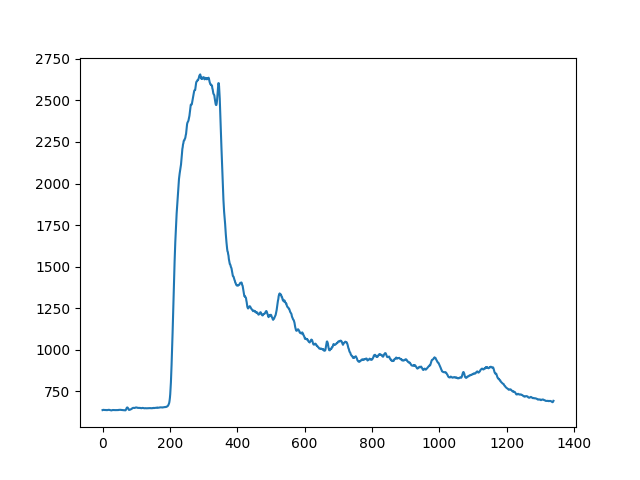

In [8]:
arr_data_proc = np.apply_along_axis(remove_rays, 0, arr_data)
print(arr_data_proc.shape)
arr_data_proc = savgol_filter(arr_data_proc, 11, 3)

plt.figure()

plt.plot(arr_data_proc[40, 40, :])

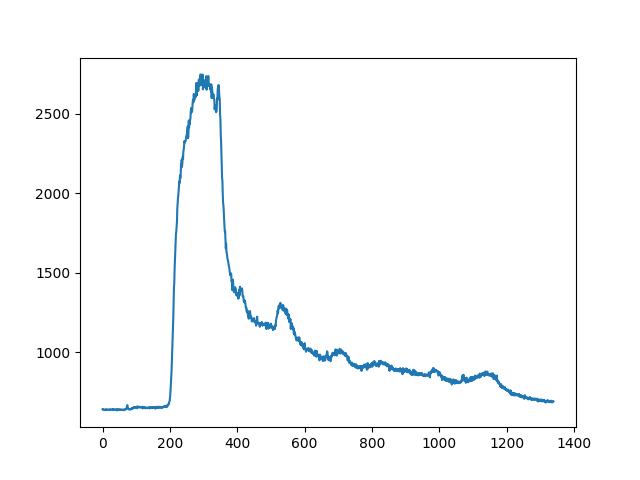

In [9]:
plt.figure()

plt.plot(arr_data[0, 10, :])

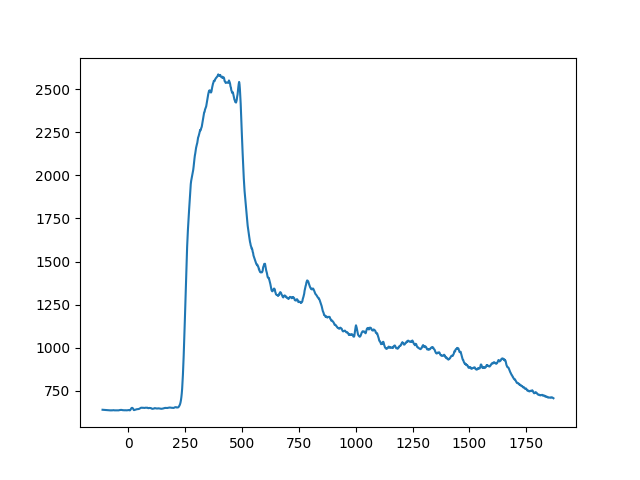

In [10]:
plt.figure()

arr_calibration = pd.read_pickle("H:/Other computers/My Computer/Salvatore/Calibration/arr_calibration202601.pickle")
plt.plot(arr_calibration, arr_data_proc[220, 276, :])

1002.6925326373361


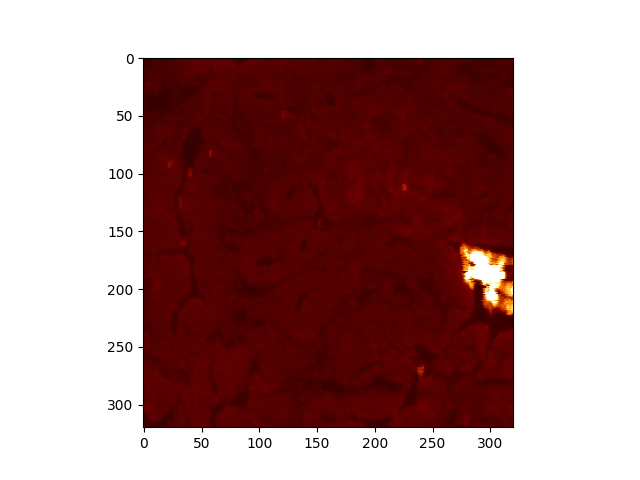

In [11]:
plt.figure()
idx = 667
print(arr_calibration[idx])
vmin = np.percentile(arr_data_proc[:, :, :], 10)
vmax = np.percentile(arr_data_proc[:, :, :], 99.5)
plt.imshow(arr_data_proc[:, :, idx], cmap='afmhot', vmin=vmin, vmax=vmax)

1002.6925326373361
992.8358974358997 1231.7342657342685


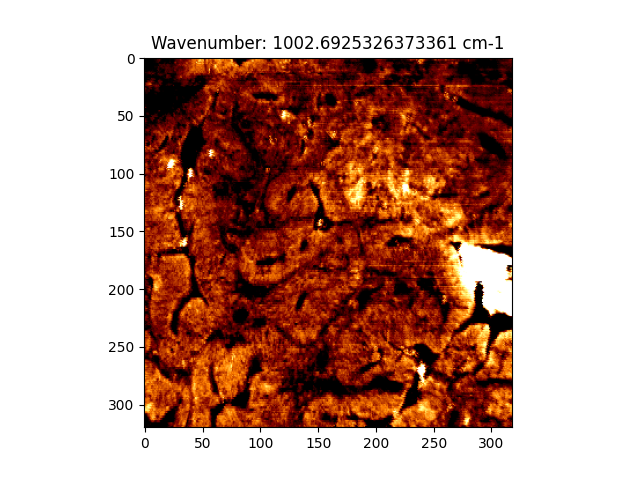

In [14]:
shift = 1
shifted = arr_data_proc.copy()
for i in range(1, arr_data_proc.shape[0], 2):  # 1, 3, 5, ...
    shifted[i, :-shift] = arr_data_proc[i, shift:]      # shift left
    shifted[i, -shift:] = 0   

idx = 667
vmin = np.percentile(shifted[:, :, idx], 10)
vmax = np.percentile(shifted[:, :, idx], 98)
plt.figure()

print(arr_calibration[idx])
plt.imshow(shifted[:, :-2, idx], cmap='afmhot', vmin=vmin, vmax=vmax)
plt.title(f"Wavenumber: {arr_calibration[idx]} cm-1")
print(vmin, vmax)

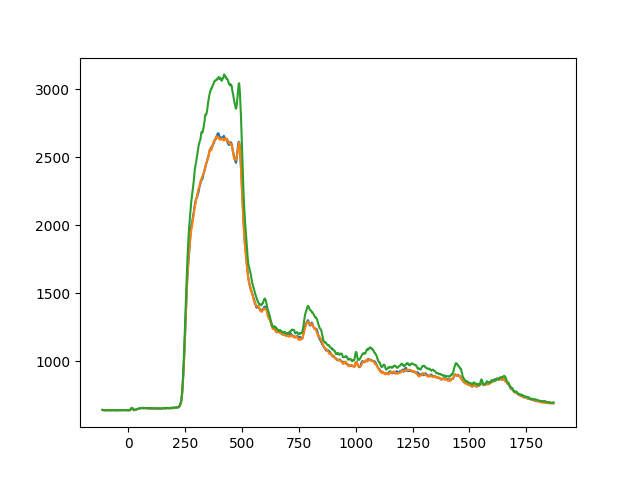

In [15]:
plt.figure()

arr_calibration = pd.read_pickle("H:/Other computers/My Computer/Salvatore/Calibration/arr_calibration202601.pickle")
plt.plot(arr_calibration, arr_data_proc[22, 23, :])
plt.plot(arr_calibration, arr_data_proc[22, 24, :])
plt.plot(arr_calibration, arr_data_proc[258, 33, :])

In [16]:
back_spectrum = shifted[:, :-2, :].min(axis=0).min(axis=0)

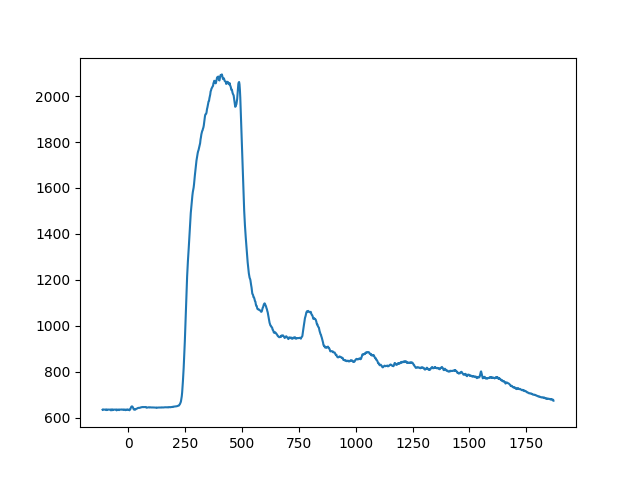

In [17]:
plt.figure()

arr_calibration = pd.read_pickle("H:/Other computers/My Computer/Salvatore/Calibration/arr_calibration202601.pickle")
plt.plot(arr_calibration, back_spectrum)

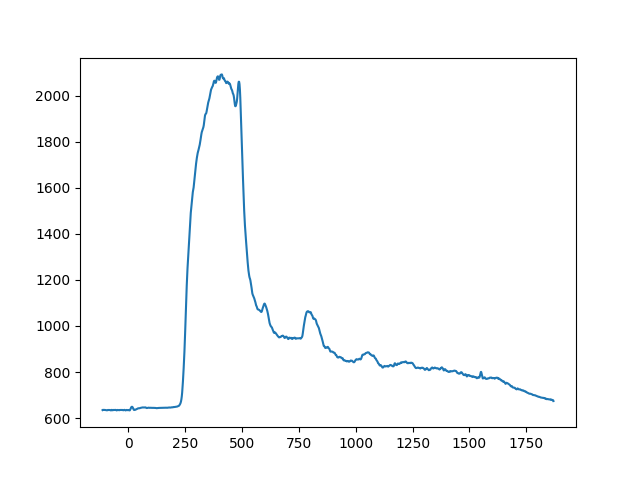

In [18]:
plt.figure()
plt.plot(arr_calibration, savgol_filter(back_spectrum, 5, 3))

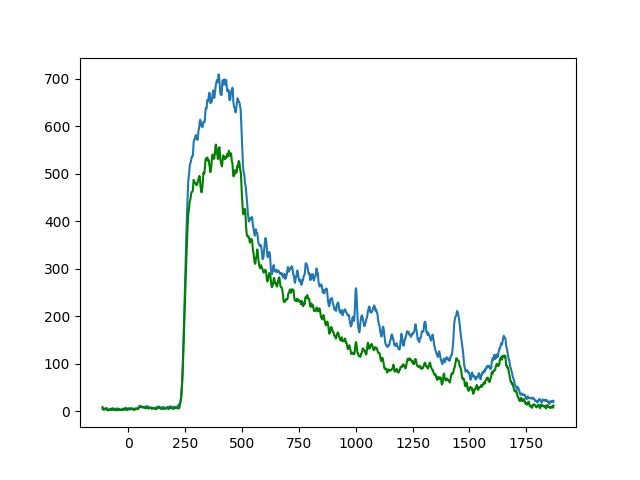

In [19]:
shifted_basesub = shifted - savgol_filter(back_spectrum, 5, 3)

plt.figure()

plt.plot(arr_calibration, savgol_filter(shifted_basesub[305, 185, :], 4, 3))
plt.plot(arr_calibration, savgol_filter(shifted_basesub[9, 14, :], 4, 3), color='green')

1002.6925326373361
113.42634032634047 28945.580419580485


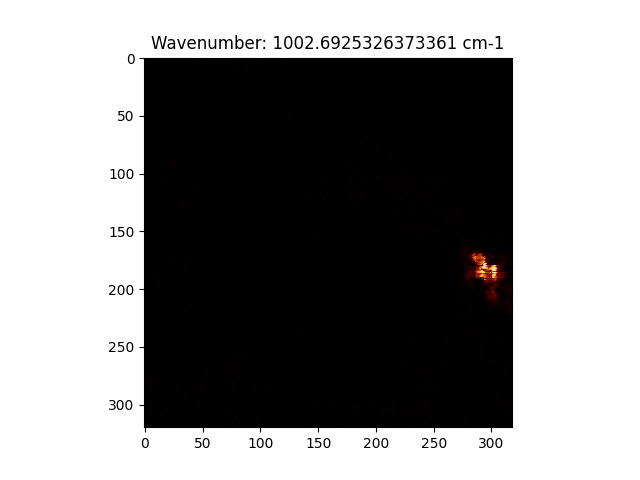

In [20]:
idx = 667
vmin = np.percentile(shifted_basesub[:, :-1, idx], 5)
vmax = np.percentile(shifted_basesub[:, :-1, idx], 99.99)
plt.figure()

print(arr_calibration[idx])
plt.imshow(shifted_basesub[:, :-2, idx], cmap='afmhot', vmin=vmin, vmax=vmax)
plt.title(f"Wavenumber: {arr_calibration[idx]} cm-1")
print(vmin, vmax)

784.6730188417677
205.7060606060609 12206.270487179834


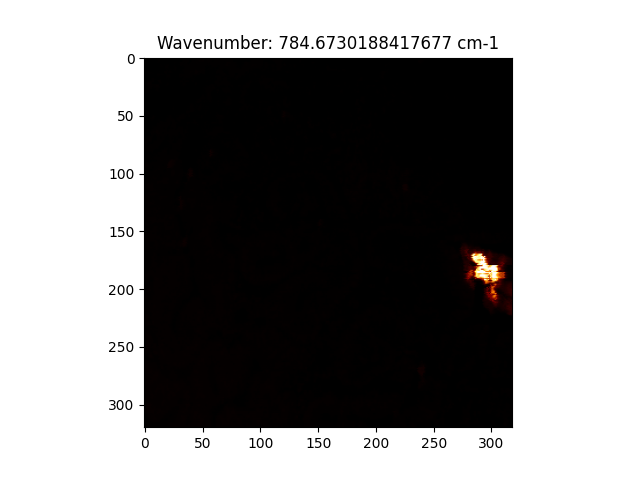

In [21]:
idx = 525
vmin = np.percentile(shifted_basesub[:, :-2, idx], 10)
vmax = np.percentile(shifted_basesub[:, :-2, idx], 99.9)
plt.figure()

print(arr_calibration[idx])
plt.imshow(shifted_basesub[:, :-2, idx], cmap='afmhot', vmin=vmin, vmax=vmax)
plt.title(f"Wavenumber: {arr_calibration[idx]} cm-1")
print(vmin, vmax)

784.6730188417677
1671.0430480908917


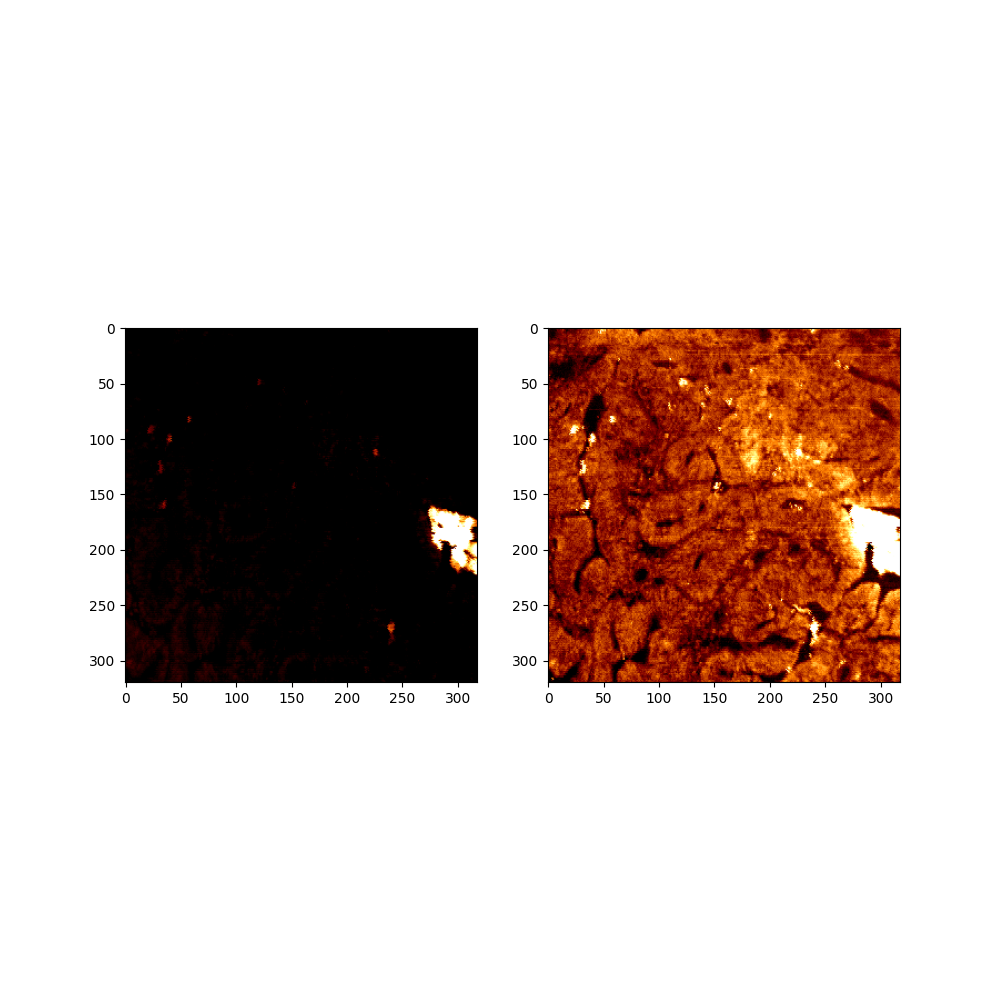

In [22]:
shifted_basesub_resh2 = shifted_basesub.copy()
idx = 525
vmin = np.percentile(shifted_basesub_resh2[:, :-2, idx], 80)
vmax = np.percentile(shifted_basesub_resh2[:, :-2, idx], 99)
fig, ax = plt.subplots(1, 2, figsize=(10, 10))

print(arr_calibration[idx])
ax[0].imshow(shifted_basesub_resh2[:, :-2, idx], cmap='afmhot', vmin=vmin, vmax=vmax)

idx2 = 1170
vmin2 = np.percentile(shifted_basesub_resh2[:, :, idx2], 1)
vmax2 = np.percentile(shifted_basesub_resh2[:, :, idx2], 98)
ax[1].imshow(shifted_basesub_resh2[:, :-2, idx2], cmap='afmhot', vmin=vmin2, vmax=vmax2)
print(arr_calibration[idx2])

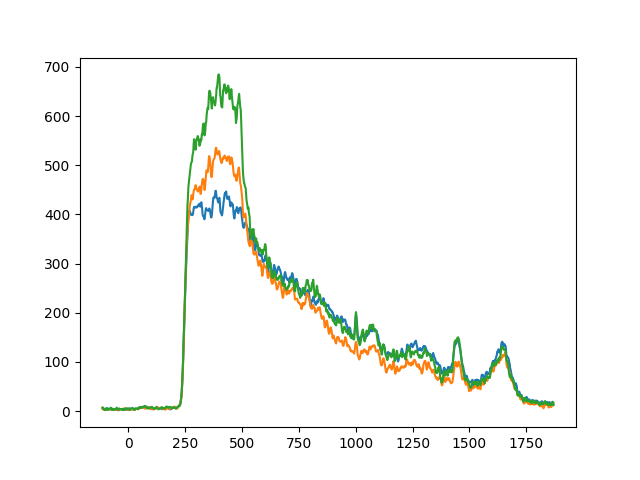

In [23]:
plt.figure()

plt.plot(arr_calibration, savgol_filter(shifted_basesub[84, 156, :], 5, 3))
plt.plot(arr_calibration, savgol_filter(shifted_basesub[94, 114, :], 5, 3))
plt.plot(arr_calibration, shifted_basesub[268, 183, :])

In [24]:
import numpy as np
import rampy as rp
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm

method = "als"  # Asymmetric Least Squares
lam = 1e5
p = 0.01
niter = 10

wv_ind = np.arange(shifted_basesub.shape[2])[300:]
roi = np.array([[np.min(wv_ind), np.max(wv_ind)]])

pixels = np.ascontiguousarray(
    shifted_basesub.reshape(-1, shifted_basesub.shape[2]).astype(np.float32, copy=False)
)[:, 300:]
N, n_w = pixels.shape

corr_flat = np.empty((N, n_w), dtype=np.float32)

chunk = 256  # try 128/256/512

def process_chunk(start):
    stop = min(start + chunk, N)
    corr_blk = np.empty((stop - start, n_w), dtype=np.float32)
    base_blk = np.empty((stop - start, n_w), dtype=np.float32)

    with threadpool_limits(limits=1):
        for k, i in enumerate(range(start, stop)):
            y = pixels[i].reshape(-1)
            corr, baseline = rp.baseline(
                wv_ind, y, roi, method=method, lam=lam, p=p, niter=niter, polynomial_order=3
            )
            corr_blk[k] = np.asarray(corr, dtype=np.float32).reshape(-1)
            base_blk[k] = np.asarray(baseline, dtype=np.float32).reshape(-1)

    return start, stop, corr_blk, base_blk

starts = list(range(0, N, chunk))

results = []

results = Parallel(n_jobs=40, backend="loky", pre_dispatch="2*n_jobs", verbose=10)(
        delayed(process_chunk)(start) for start in starts
    )

for start, stop, corr_blk, base_blk in results:
    corr_flat[start:stop] = corr_blk



[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done   5 tasks      | elapsed:   17.8s
[Parallel(n_jobs=40)]: Done  18 tasks      | elapsed:   18.1s
[Parallel(n_jobs=40)]: Done  33 tasks      | elapsed:   19.0s
[Parallel(n_jobs=40)]: Done  48 tasks      | elapsed:   30.3s
[Parallel(n_jobs=40)]: Done  65 tasks      | elapsed:   31.4s
[Parallel(n_jobs=40)]: Done  82 tasks      | elapsed:   41.7s
[Parallel(n_jobs=40)]: Done 101 tasks      | elapsed:   44.0s
[Parallel(n_jobs=40)]: Done 120 tasks      | elapsed:   48.7s
[Parallel(n_jobs=40)]: Done 141 tasks      | elapsed:   56.8s
[Parallel(n_jobs=40)]: Done 162 tasks      | elapsed:  1.1min
[Parallel(n_jobs=40)]: Done 185 tasks      | elapsed:  1.2min
[Parallel(n_jobs=40)]: Done 208 tasks      | elapsed:  1.3min
[Parallel(n_jobs=40)]: Done 233 tasks      | elapsed:  1.4min
[Parallel(n_jobs=40)]: Done 258 tasks      | elapsed:  1.6min
[Parallel(n_jobs=40)]: Done 285 tasks      | elapsed:  

In [25]:
shifted_basesub_resh = np.array(corr_flat).reshape(320, 320, -1)  #use the same reshape size as in the first lines

print(shifted.shape)

(320, 320, 1340)


In [27]:
shifted_basesub_resh[82, 108, :].shape

(1040,)

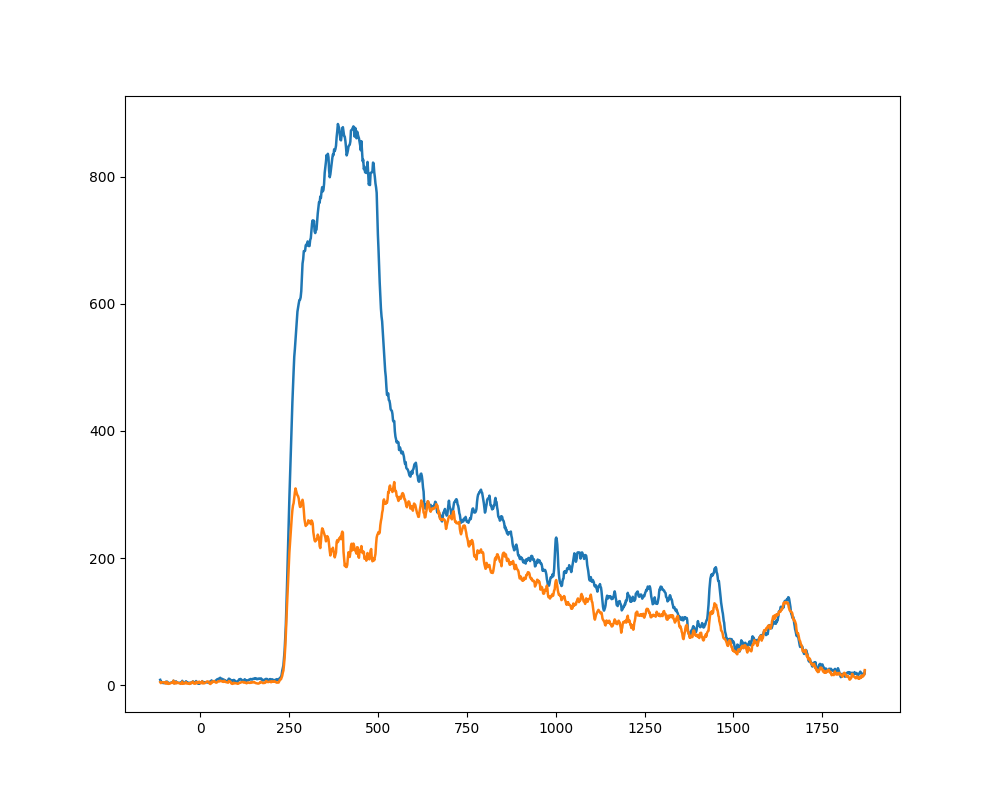

In [28]:
plt.figure(figsize=(10, 8))

plt.plot(arr_calibration[:], shifted_basesub[252,94, :], linewidth=1.8)
plt.plot(arr_calibration[:], shifted_basesub[71, 262, :], linewidth=1.8)

1441.4813753557253
784.6730188417677
1659.0698714580537


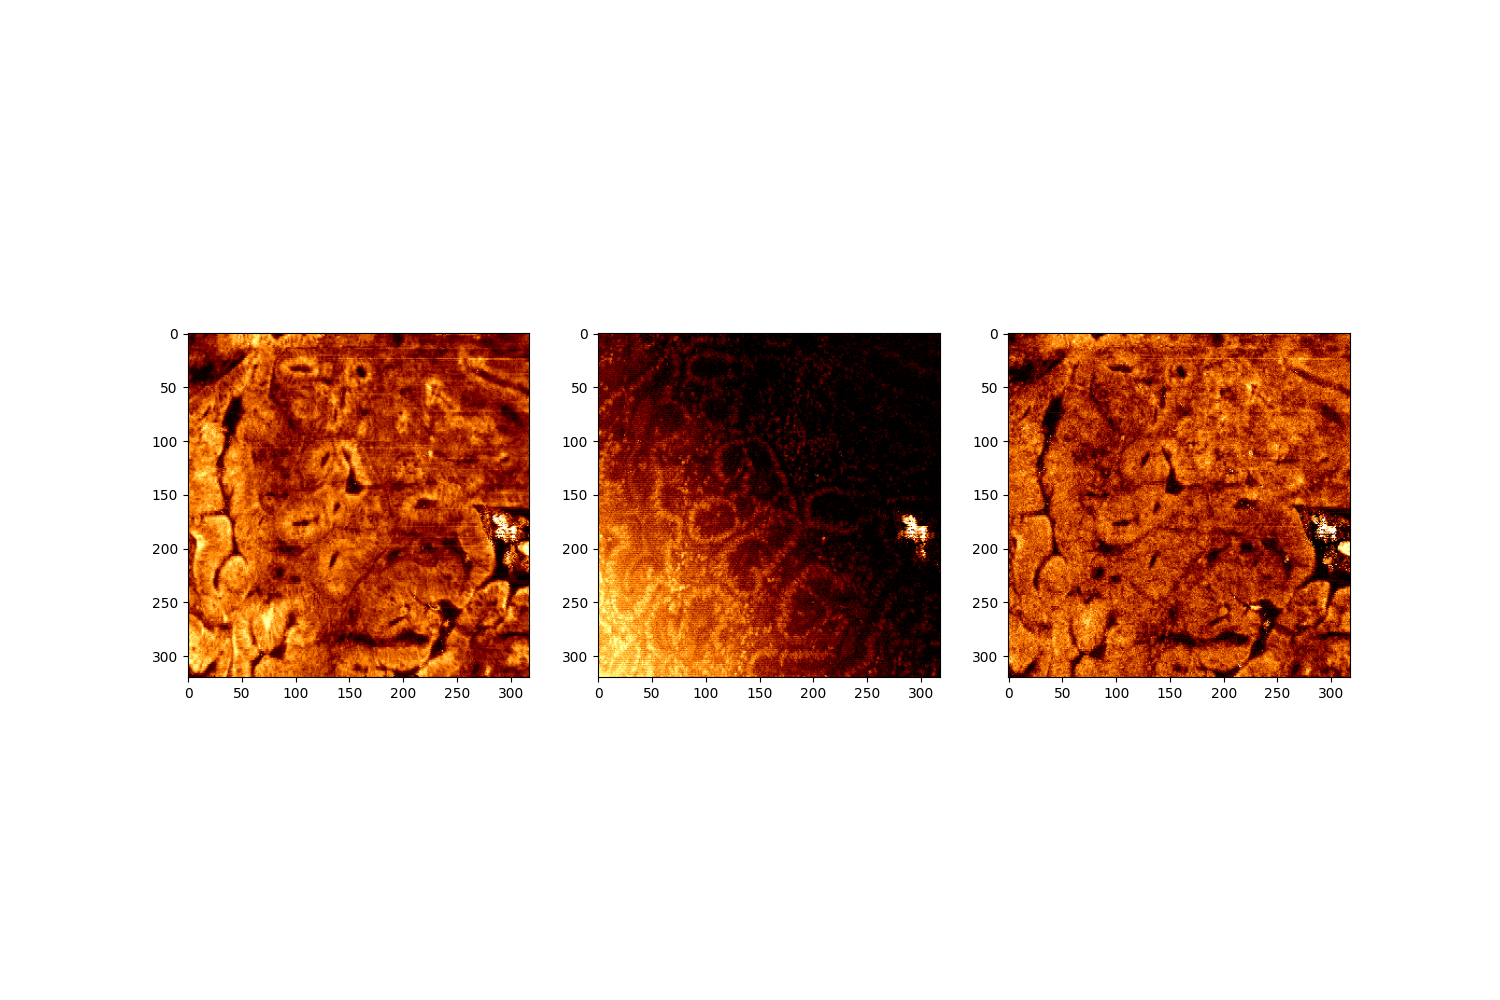

In [29]:
shifted_basesub_resh2 = shifted_basesub_resh.copy() - np.expand_dims(shifted_basesub_resh.min(axis=2), axis=2)
idx = 982
vmin = np.percentile(shifted_basesub_resh2[:, :-2, idx-300], 0.1)
vmax = np.percentile(shifted_basesub_resh2[:, :-2, idx-300], 99.9)
fig, ax = plt.subplots(1, 3, figsize=(15, 10))

print(arr_calibration[idx])
ax[0].imshow(shifted_basesub_resh2[:, :-2, idx-300], cmap='afmhot', vmin=vmin, vmax=vmax)

idx2 = 525
vmin2 = np.percentile(shifted_basesub_resh2[:, :, idx2-300], 20)
vmax2 = np.percentile(shifted_basesub_resh2[:, :, idx2-300], 99.9)
ax[1].imshow(shifted_basesub_resh2[:, :-2, idx2-300], cmap='afmhot', vmin=vmin2, vmax=vmax2)
print(arr_calibration[idx2])


idx3 = 1160
vmin2 = np.percentile(shifted_basesub_resh2[:, :, idx3-300], 1)
vmax2 = np.percentile(shifted_basesub_resh2[:, :, idx3-300], 99.9)
ax[2].imshow(shifted_basesub_resh2[:, :-2, idx3-300], cmap='afmhot', vmin=vmin2, vmax=vmax2)
print(arr_calibration[idx3])

In [34]:
pd.to_pickle(shifted_basesub_resh2, os.path.join(directory, 'm1260614A_#3_confocal_raman_img.pickle'))